# Get to Know a Dataset: CTrees CONUS Canopy Height & Cover at 5 m

This notebook is a guided tour of CTrees' **CONUS canopy tree height and cover at 5 m**,
derived from NAIP aerial imagery and published as an [Icechunk](https://icechunk.io)
repository on [Arraylake](https://docs.earthmover.io).

More usage examples, tutorials, and documentation for this dataset and others can be
found at the [Registry of Open Data on AWS](https://registry.opendata.aws/).

> **TODO before publishing:** link the Registry of Open Data landing page for this
> dataset once the entry is live.

**The question this notebook answers:** *Can we see the 2021 caldor Fire in this
dataset — and how much canopy did it destroy?*

We will not tell the notebook where the fire was. We will open a rectangular window
over the region, difference the two years, and let the burn scar appear on its own.

## Before you start

Create the environment and authenticate once, from a terminal:

```sh
conda env create -f environment.yml
conda activate ctrees-tree-height-env

al auth login      # opens a browser; caches a session locally
```

`al auth login` is the only authentication step. **This notebook never reads an API
key or token** — `arraylake.Client()` picks up the cached session automatically.

### Q: How have you organized your dataset?

The dataset is a single Icechunk repository, `ctrees/tree-height-naip-5m-conus`, on
Arraylake. Inside it, data is organised as **one Zarr group per state**, named by its
two-letter postal code:

```
ctrees/tree-height-naip-5m-conus        <- Icechunk repository
└── branch: main
    ├── AL/                             <- one Zarr group per state (48 CONUS states)
    ├── AR/
    ├── ...
    └── CA/
        ├── tree_height             (time, y, x)  uint8   <- metres
        ├── tree_cover              (time, y, x)  uint8   <- 0 = non-forest, 1 = forest
        ├── tree_cover_percentage   (time, y, x)  uint8   <- whole percent, 0-100
        ├── time                                          <- NAIP acquisition years
        ├── y, x                                          <- EPSG:4326 pixel centres
        └── spatial_ref                                   <- CRS metadata (scalar)
```

**Why one group per state?** NAIP flies on a state-by-state cycle, so each state has
its own set of acquisition years. Alabama has 2021 and 2023; California has 2020 and
2022; Nevada has only 2022. Four states have non-contiguous year sets. Forcing all 48
onto a shared time axis would have fabricated phantom, entirely-nodata years, so
**each state group carries its own `time` coordinate**. Check it per state rather than
assuming.

**Grid.** Every group sits on one globally-aligned EPSG:4326 grid with a step of
`0.00004°` (1/25000 of a degree, about 4.42 m of latitude), with pixel edges at exact
multiples of that step measured from (-180, +90). Arrays are chunked `512 x 512` and
sharded `4096 x 4096`, so 64 chunks share one object in storage — which is why reading
a small window stays cheap despite the dataset's size.

**Coverage is not uniform.** Each state's array spans its bounding box, but NAIP
coverage within that box is partial: California is about 46% populated, Colorado 100%.
Absent regions read as the fill value, not as an error.

In [6]:
# This notebook requires the following libraries. Install them with the supplied
# environment.yml (see "Before you start" above):
#
# arraylake >= 1.6
# icechunk == 2.2.2
# xarray >= 2025.1
# zarr >= 3
# dask
# rioxarray >= 0.18
# geopandas >= 1.0
# matplotlib >= 3.8
# numpy >= 2.0

import numpy as np
import xarray as xr
import geopandas as gpd
import rioxarray  # noqa: F401 -- importing it registers the .rio accessor
import matplotlib.pyplot as plt
import dask
import dask.array as dsa
import zarr

from arraylake import Client

# Dask defaults to one worker thread per CPU core, which puts that many decoded
# chunks in flight at once. These arrays decode to float32, so on a laptop that
# is the difference between running comfortably and swapping. Raise it on a
# larger machine; lower it further if you are memory-constrained.
dask.config.set(scheduler="threads", num_workers=4)

First we connect to Arraylake and open the repository. `Client()` takes no arguments —
it uses the session cached by `al auth login`.

In [7]:
REPO = "ctrees/tree-height-naip-5m-conus"
BRANCH = "main"

client = Client()
repo = client.get_repo(REPO)

# A read-only session pins every read in this notebook to a single snapshot, so the
# numbers below stay consistent even if the dataset is updated while you work.
session = repo.readonly_session(branch=BRANCH)

Now let's list the state groups in the repository. There is one per CONUS state.

In [8]:
root = zarr.open_group(session.store, mode="r")
states = sorted(root.group_keys())

print(f"{len(states)} state groups:")
print(", ".join(states))

48 state groups:
AL, AR, AZ, CA, CO, CT, DE, FL, GA, IA, ID, IL, IN, KS, KY, LA, MA, MD, ME, MI, MN, MO, MS, MT, NC, ND, NE, NH, NJ, NM, NV, NY, OH, OK, OR, PA, RI, SC, SD, TN, TX, UT, VA, VT, WA, WI, WV, WY


Let's open California and look at its structure. Passing `chunks={}` keeps the arrays
lazy — xarray reads the metadata now and fetches pixels only when a computation
actually needs them. That matters here: California's full array is billions of pixels.

In [9]:
STATE = "CA"

ds = xr.open_zarr(session.store, group=STATE, zarr_format=3, chunks={})
ds

<xarray.Dataset> Size: 2TB
Dimensions:                (time: 2, y: 245760, x: 262144)
Coordinates:
  * time                   (time) datetime64[ns] 16B 2020-01-01 2022-01-01
  * y                      (y) float64 2MB 42.16 42.16 42.16 ... 32.33 32.33
  * x                      (x) float64 2MB -124.5 -124.5 ... -114.0 -114.0
    spatial_ref            int64 8B ...
Data variables:
    tree_cover_percentage  (time, y, x) float32 515GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    tree_height            (time, y, x) float32 515GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    tree_cover             (time, y, x) float32 515GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
Attributes:
    Conventions:            CF-1.8
    title:                  CONUS NAIP-derived Canopy Tree Height and Cover, 5m
    state:                  CA
    temporal_resolution:    annual composite
    years:                  [2020, 2022]
    source_grid:            Planet L15 (EPSG:3857, 2048x2048 quads), warped t...
    grid:                   regular EPSG:4326, 4e-05 deg, globally aligned fr...
    nominal_resolution_m:   4.423
    area_calculation_note:  This is a regular latitude/longitude grid, which ...

Note the `time` coordinate — **2020 and 2022** for California, the two NAIP
acquisitions that bracket the Caldor Fire.

In [11]:
print("Acquisition years for", STATE, ":", list(ds.time.dt.year.values))
print()
for name in ("tree_height", "tree_cover", "tree_cover_percentage"):
    v = ds[name]
    print(f"{name}")
    print(f"    dtype in memory  {v.dtype}            <- decoded")
    print(f"    dtype in storage {v.encoding.get('dtype')}            <- as stored")
    print(f"    fill value       {v.encoding.get('_FillValue')}")
    print(f"    shape            {v.shape}")
    print(f"    chunks           {v.encoding.get('chunks')}")
    print(f"    units            {v.attrs.get('units', '-')}")
    print(f"    resampling       {v.attrs.get('resampling', '-')}")
    print()

# The group itself carries a warning about area calculations. Worth reading.
print("area_calculation_note:")
print(" ", ds.attrs.get("area_calculation_note", "<absent>"))

Acquisition years for CA : [np.int64(2020), np.int64(2022)]

tree_height
    dtype in memory  float32            <- decoded
    dtype in storage uint8            <- as stored
    fill value       255
    shape            (2, 245760, 262144)
    chunks           (1, 512, 512)
    units            meters
    resampling       average

tree_cover
    dtype in memory  float32            <- decoded
    dtype in storage uint8            <- as stored
    fill value       255
    shape            (2, 245760, 262144)
    chunks           (1, 512, 512)
    units            -
    resampling       nearest

tree_cover_percentage
    dtype in memory  float32            <- decoded
    dtype in storage uint8            <- as stored
    fill value       255
    shape            (2, 245760, 262144)
    chunks           (1, 512, 512)
    units            percent
    resampling       average

area_calculation_note:
  This is a regular latitude/longitude grid, which is NOT equal-area: cell ground area varie

Four things in that output are worth pausing on, because they change how you should
interpret any number you compute from this dataset.

**The fill value is 255, and xarray has already handled it.** The arrays are stored as
`uint8` with a CF `_FillValue` of 255. On open, xarray's default decoding promotes them
to `float32` and replaces every 255 with `NaN` — which is why "dtype in memory" and
"dtype in storage" differ above. **You do not need to mask 255 yourself**, and every
`mean`, `sum` and `std` below skips those cells automatically.

Two situations where you *must* mask by hand: if you open with `mask_and_scale=False`,
or if you read the arrays through `zarr` directly rather than `xarray`. In both cases
the raw 255s come through as data. Getting this wrong is quiet and expensive — treating
255 as a height puts 255-metre trees in your statistics, and treating it as zero
silently converts "no imagery here" into "no trees here". Note that **zero is a real,
meaningful value**: bare ground.

**`tree_height` is a median, not a mean.** Each 5 m value is the median of the native
60 cm NAIP height predictions falling inside it. Canopy heights within a cell are
right-skewed, so the median sits *below* the mean — measured on this product, the mean
exceeds the median at about 65% of vegetated pixels. This is the right statistic for a
robust summary, but it is not interchangeable with a mean, so if you compare against
another product, check which one that product reports. The sibling 30 m dataset ships
`tree_height_mean` and `tree_height_std` alongside the median for exactly this reason.

Note that the `resampling: average` attribute above does **not** contradict this. It
records how pixels were combined when the data was warped onto this grid, which is a
separate question from which statistic the source value represents.

**`tree_cover_percentage` is stored as whole percent, 0-100.** The stored value *is*
the percentage — there is no CF `scale_factor` to apply and nothing to decode, as its
`source_transform` attribute says explicitly. Do not divide by anything.

### Q: What data formats are present in your dataset?

#### Zarr

[Zarr](https://zarr.dev) stores chunked, compressed, N-dimensional arrays in a layout
designed for cloud object storage. Rather than one monolithic file, a Zarr store is a
collection of small objects, so a reader can fetch exactly the spatial and temporal
subset it needs. Reading one county out of a CONUS-wide array touches only the objects
covering that county.

These arrays are **Zarr v3 and sharded**: the chunk is `512 x 512`, but 64 chunks are
packed into one `4096 x 4096` shard object. Sharding keeps the object count manageable
(this dataset would otherwise run to millions of tiny objects) without forcing readers
to download a 16 MB shard to get a 256 KB chunk.

#### Icechunk

[Icechunk](https://icechunk.io) is a transactional storage engine layered on Zarr. It
adds Git-like version control:

- **Branches** — `main` is the authoritative version. Authors may keep other branches
  for experiments or alternative processing runs.
- **Snapshots (commits)** — every update is recorded, so the dataset is reproducible at
  any point in its history.
- **Sessions** — `readonly_session` pins all your reads to one snapshot, so a long
  analysis cannot see the dataset change underneath it.

You do not need to understand Icechunk's internals to use this data. The workflow is:
open the repo → open a read-only session → hand `session.store` to `xarray`.

#### Recommended tooling

`xarray` for labelled access, `dask` (via `chunks={}`) to keep large reads lazy,
`rioxarray` for CRS-aware clipping and GeoTIFF export, and `geopandas` for vector AOIs.

#### Multiscale overviews

The repository also carries GeoZarr overview pyramids on a separate branch, for viewing
a whole state at once without reading native resolution, and these render directly in
the Earthmover viewer and through its Flux tile service. This notebook reads native
resolution because we want the statistics computed from real pixels — but for
state-wide or CONUS-wide *visualisation*, reach for the pyramids rather than
downsampling the native arrays yourself.

### Q: Can you show us an example of downloading and loading data?

We load an area of interest and use it to cut a window out of the California array.

The AOI shipped with this notebook (`aoi/caldor_fire_shape.shp`) is a **rectangle drawn
loosely around the caldor Fire region** — deliberately, not the official burn perimeter.
That is the point of the exercise: we are going to find the fire in the data rather
than be told where it is. It also means the window contains a great deal of unburned
forest, which matters for how we compute statistics later.

`geopandas` reads both Shapefiles and GeoJSON. If you use a Shapefile, remember its
sidecar files (`.dbf`, `.shx`, `.prj`, `.cpg`) must sit alongside it.

In [12]:
AOI_PATH = "aoi/caldor_fire_aoi.shp"   # <- replace with your own AOI if you like

aoi = gpd.read_file(AOI_PATH).to_crs("EPSG:4326")
aoi_geom = aoi.geometry.union_all()     # dissolve, in case of multiple features
minx, miny, maxx, maxy = aoi_geom.bounds

# Is this AOI a plain rectangle, or a real outline? It changes whether clipping does
# any work beyond the bounding-box selection.
is_rectangle = aoi_geom.equals(aoi_geom.envelope)

print(f"AOI bounds (EPSG:4326): {minx:.5f}, {miny:.5f}, {maxx:.5f}, {maxy:.5f}")
print(f"extent: {maxx - minx:.4f} deg lon x {maxy - miny:.4f} deg lat")
print(f"features: {len(aoi)}   rectangle: {is_rectangle}")

AOI bounds (EPSG:4326): -120.55587, 38.51510, -120.07321, 38.81377
extent: 0.4827 deg lon x 0.2987 deg lat
features: 1   rectangle: True


Now subset the California array to that window.

Note the `y` slice runs **north to south** (`maxy, miny`). The `y` coordinate descends,
matching north-up raster convention, and `.sel()` with a slice follows the coordinate's
own order. Reversing it silently returns an empty selection.

In [13]:
# Crop spatially first -- this is what keeps the read manageable.
sub = ds.sel(x=slice(minx, maxx), y=slice(maxy, miny))

n_px = sub.sizes["y"] * sub.sizes["x"]
print("Window shape (time, y, x):", dict(sub.sizes))
print(f"{n_px / 1e6:,.0f} million pixels per variable-year "
      f"({n_px / 1e9:.2f} GB as uint8)")
sub

Window shape (time, y, x): {'time': 2, 'y': 7466, 'x': 12067}
90 million pixels per variable-year (0.09 GB as uint8)


<xarray.Dataset> Size: 2GB
Dimensions:                (time: 2, y: 7466, x: 12067)
Coordinates:
  * time                   (time) datetime64[ns] 16B 2020-01-01 2022-01-01
  * y                      (y) float64 60kB 38.81 38.81 38.81 ... 38.52 38.52
  * x                      (x) float64 97kB -120.6 -120.6 ... -120.1 -120.1
    spatial_ref            int64 8B ...
Data variables:
    tree_cover_percentage  (time, y, x) float32 721MB dask.array<chunksize=(1, 344, 233), meta=np.ndarray>
    tree_height            (time, y, x) float32 721MB dask.array<chunksize=(1, 344, 233), meta=np.ndarray>
    tree_cover             (time, y, x) float32 721MB dask.array<chunksize=(1, 344, 233), meta=np.ndarray>
Attributes:
    Conventions:            CF-1.8
    title:                  CONUS NAIP-derived Canopy Tree Height and Cover, 5m
    state:                  CA
    temporal_resolution:    annual composite
    years:                  [2020, 2022]
    source_grid:            Planet L15 (EPSG:3857, 2048x2048 quads), warped t...
    grid:                   regular EPSG:4326, 4e-05 deg, globally aligned fr...
    nominal_resolution_m:   4.423
    area_calculation_note:  This is a regular latitude/longitude grid, which ...

Select the two years, and clip to the AOI outline if it is something more interesting
than a rectangle.

There is no masking step here — xarray decoded the fill value to `NaN` when we opened
the dataset, which is also why these arrays are `float32` in memory rather than the
`uint8` they are in storage. Everything stays **lazy**: nothing has been read from
storage yet.

In [14]:
def prepare(var_name):
    # No manual fill masking needed: xarray decoded _FillValue (255) to NaN on open.
    da = sub[var_name]
    if not is_rectangle:
        # Only worth the work for a real outline; for a rectangle the bounding-box
        # selection above has already done it.
        da = da.rio.write_crs("EPSG:4326").rio.clip([aoi_geom], crs="EPSG:4326", drop=True)
    return da

height = prepare("tree_height")
cover = prepare("tree_cover")

h_2020 = height.sel(time="2020-01-01")
h_2022 = height.sel(time="2022-01-01")
c_2020 = cover.sel(time="2020-01-01")
c_2022 = cover.sel(time="2022-01-01")

print("Still lazy:", type(h_2020.data).__name__, "| chunks:", h_2020.chunks[0][:3], "...")

Still lazy: Array | chunks: (344, 512, 512) ...


**One caveat specific to this window.** Of the 81 source quads covering it, 80 are
present in both years; one is present in 2022 but absent from 2020. It reads as fill,
so it is already masked — but it means a small corner contributes to the 2022 map and
to neither of the difference statistics. Any honest before/after comparison has to
restrict itself to pixels valid in **both** years, which is what we do now.

In [15]:
# Only pixels with valid data in BOTH years can contribute to a difference.
valid_both = h_2020.notnull() & h_2022.notnull()

h_2020 = h_2020.where(valid_both)
h_2022 = h_2022.where(valid_both)
c_2020 = c_2020.where(valid_both)
c_2022 = c_2022.where(valid_both)

delta = h_2022 - h_2020          # negative = canopy lost

# Still nothing read: every line above just extends the dask graph. The actual
# count of valid pixels is reported further down, from the single pass that
# computes all of this notebook's statistics at once.
print("Graph built. Arrays remain lazy:", type(delta.data).__name__)

Graph built. Arrays remain lazy: Array


### Q: A picture is worth a thousand words

Here is the fire.

A billion pixels will not fit through matplotlib, and there is no point sending it
more points than the figure has dots. We coarsen for display only — every statistic
later in the notebook is computed from the full-resolution data.

In [16]:
CHUNK_PX = 512   # the on-disk chunk size of these arrays

def for_display(da, max_px=1100, chunk_px=CHUNK_PX):
    # Block-average down to something a figure can actually draw.
    #
    # The factor MUST divide the chunk size. A factor that straddles chunk
    # boundaries forces dask to rechunk -- it then assembles each output block
    # from pieces of several input chunks, holding them all in memory at once.
    # On a window this size that is the difference between running and an OOM.
    want = max(da.sizes["y"], da.sizes["x"]) / max_px
    divisors = [d for d in (1, 2, 4, 8, 16, 32, 64, 128, 256, 512) if chunk_px % d == 0]
    factor = min(divisors, key=lambda d: abs(d - want))
    if factor <= 1:
        return da
    return da.coarsen(y=factor, x=factor, boundary="trim").mean()

# One dask.compute for all three, so the arrays are read once rather than
# three times over.
disp_2020, disp_2022, disp_delta = dask.compute(
    for_display(h_2020), for_display(h_2022), for_display(delta)
)
print("Display grid:", dict(disp_delta.sizes))

Display grid: {'y': 933, 'x': 1508}


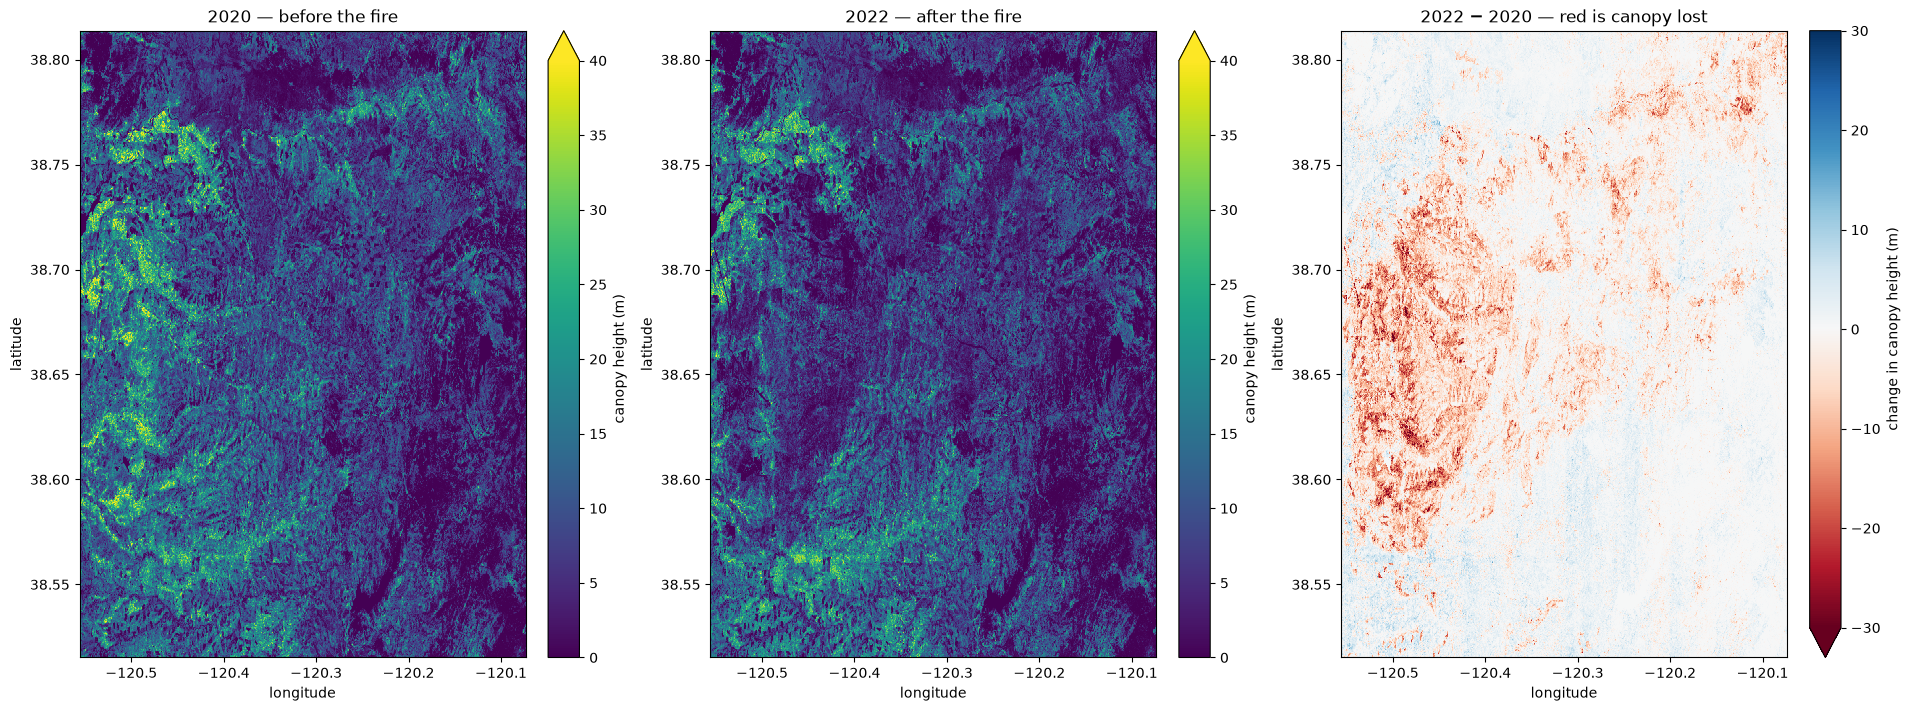

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(19, 7), constrained_layout=True)

disp_2020.plot(ax=axes[0], vmin=0, vmax=40, cmap="viridis",
               cbar_kwargs={"label": "canopy height (m)"})
axes[0].set_title("2020 — before the fire")

disp_2022.plot(ax=axes[1], vmin=0, vmax=40, cmap="viridis",
               cbar_kwargs={"label": "canopy height (m)"})
axes[1].set_title("2022 — after the fire")

disp_delta.plot(ax=axes[2], vmin=-30, vmax=30, cmap="RdBu",
                cbar_kwargs={"label": "change in canopy height (m)"})
axes[2].set_title("2022 − 2020 — red is canopy lost")

for ax in axes:
    ax.set_xlabel("longitude")
    ax.set_ylabel("latitude")

plt.show()

The third panel is the result worth dwelling on. **We never supplied a burn perimeter** —
the AOI is a plain rectangle. The shape picked out in red is the caldor Fire, drawn
entirely by the difference between two years of canopy height.

### Q: What is one question you have answered using these data?

**How much canopy did the Caldor Fire destroy?**

To answer that we need canopy *area*, and that is where this dataset's grid demands
care.

#### The pixel-counting trap

The data is on a regular latitude/longitude grid (EPSG:4326), which is **not
equal-area**. A cell spans a fixed number of degrees, but a degree of longitude shrinks
as `cos(latitude)` — so a cell here covers meaningfully less ground than one on the Gulf
coast. **Counting pixels and multiplying by a nominal cell size gives the wrong
answer**, and the error is systematic rather than noisy.

The correct cell area for a lat/lon grid comes from the spherical zone formula: a cell
spanning `Δλ` of longitude between latitudes `φ_s` and `φ_n` has area
`R² · Δλ · (sin φ_n − sin φ_s)`. It depends only on latitude, so it is one column
broadcast across each row.

> **Heads up on the next few cells.** This window is about 1.06 billion pixels per
> variable-year, and we use four of them. The cell that computes the statistics is
> where that data is actually read, so expect it to take a few minutes. It is written
> as a single `dask.compute` over every statistic at once, so the arrays are read
> **once** rather than once per number — and all the block-averaging in this notebook
> uses factors that divide the 512-pixel chunk size, which avoids a rechunk that would
> otherwise push memory use past what a laptop has. If you are resource-constrained,
> shrink the AOI rather than reaching for a bigger machine.

In [18]:
R_AUTHALIC_M = 6_371_007.181          # authalic radius of the WGS84 ellipsoid, metres
STEP_DEG = 0.00004                    # this dataset's grid step

def cell_area_m2(lat_centres, step_deg=STEP_DEG, radius=R_AUTHALIC_M):
    # Exact ground area of each grid cell, as a function of latitude.
    # A cell spanning `step_deg` of longitude between latitudes phi_s and phi_n
    # has area R^2 * d_lambda * (sin phi_n - sin phi_s).
    half = step_deg / 2.0
    north = np.radians(lat_centres + half)
    south = np.radians(lat_centres - half)
    return np.radians(step_deg) * radius**2 * (np.sin(north) - np.sin(south))

# A 1-D array over y, broadcast across x by xarray's label alignment.
area = xr.DataArray(
    cell_area_m2(h_2020.y.values),
    coords={"y": h_2020.y}, dims=("y",), name="cell_area_m2",
)

print(f"Cell area at the south edge: {float(area.isel(y=-1)):.4f} m^2")
print(f"Cell area at the north edge: {float(area.isel(y=0)):.4f} m^2")
print(f"Nominal 4.42 m square:       {4.42**2:.4f} m^2")
print(f"The nominal figure overstates true area by "
      f"{4.42**2 / float(area.mean()) - 1:.1%} at this latitude.")

Cell area at the south edge: 15.4790 m^2
Cell area at the north edge: 15.4146 m^2
Nominal 4.42 m square:       19.5364 m^2
The nominal figure overstates true area by 26.5% at this latitude.


In [19]:
NOMINAL_M = 4.42        # 0.00004 deg of latitude, in metres
LOSS_THRESHOLD_M = -5.0 # how much height a pixel must lose to count as canopy loss

canopy_2020 = (c_2020 == 1)
canopy_2022 = (c_2022 == 1)
was_canopy = canopy_2020
delta_canopy = delta.where(was_canopy)
scar = was_canopy & (delta < LOSS_THRESHOLD_M)

# EVERY number in the rest of this notebook is requested here, in ONE
# dask.compute. Dask then reads each chunk once and feeds all the reductions
# from it. Calling .compute() separately per statistic would re-read the whole
# window each time -- six or seven passes over several GB instead of one.
jobs = {
    "n_valid":        valid_both.sum(),
    "px_2020":        canopy_2020.sum(),
    "px_2022":        canopy_2022.sum(),
    "area_2020":      (canopy_2020 * area).sum(),
    "area_2022":      (canopy_2022 * area).sum(),
    "scar_area":      (scar * area).sum(),
    "scar_px":        scar.sum(),
    "h_scar_2020":    h_2020.where(scar).mean(),
    "h_scar_2022":    h_2022.where(scar).mean(),
    "mean_change_all": delta_canopy.mean(),
    "loss_gt10":      (delta_canopy < -10).sum(),
    "loss_gt20":      (delta_canopy < -20).sum(),
    "hist_counts":    dsa.histogram(delta_canopy.data, bins=140, range=(-50, 20))[0],
}

R = dict(zip(jobs, dask.compute(*jobs.values())))
R = {k: (v if k == "hist_counts" else float(v)) for k, v in R.items()}

print(f"Pixels valid in both years: {R['n_valid']:,.0f} of {valid_both.size:,} "
      f"({R['n_valid'] / valid_both.size:.1%})")

Pixels valid in both years: 90,092,222 of 90,092,222 (100.0%)


In [20]:
naive_2020 = R["px_2020"] * NOMINAL_M**2 / 1e6      # km^2
naive_2022 = R["px_2022"] * NOMINAL_M**2 / 1e6
true_2020 = R["area_2020"] / 1e6
true_2022 = R["area_2022"] / 1e6

print(f"{'':30s}{'2020':>12s}{'2022':>12s}")
print(f"{'naive pixel count (km^2)':30s}{naive_2020:12.1f}{naive_2022:12.1f}   <- WRONG")
print(f"{'true ground area  (km^2)':30s}{true_2020:12.1f}{true_2022:12.1f}   <- correct")
print()
print(f"The naive method overstates canopy area by "
      f"{abs(naive_2020 - true_2020) / true_2020:.1%}.")
print()
print(f"Net canopy area lost across the window: {true_2020 - true_2022:,.1f} km^2 "
      f"({(true_2020 - true_2022) / true_2020:.1%} of 2020 canopy)")

                                      2020        2022
naive pixel count (km^2)            1267.3      1167.3   <- WRONG
true ground area  (km^2)            1002.0       923.0   <- correct

The naive method overstates canopy area by 26.5%.

Net canopy area lost across the window: 79.0 km^2 (7.9% of 2020 canopy)


#### Isolating the burn scar

That last figure is a net change across the **whole 16,000 km² window**, most of which
never burned. The fire itself covered roughly 3,900 km². Averaging over the window
therefore dilutes the signal by about fourfold and badly understates how severe the
fire was where it actually burned.

Since the scar is plainly visible in the difference, we can delineate it **from the
data** and report statistics inside it. We define the scar as pixels that were canopy
in 2020 and lost more than 5 m of height by 2022.

This is a measurement of canopy loss, not of fire *per se* — see the caveats below.

In [26]:
scar_area_km2 = R["scar_area"] / 1e6

print(f"Detected canopy-loss area: {scar_area_km2:,.0f} km^2")
print(f"  as a share of 2020 canopy in the window: {R['scar_px'] / R['px_2020']:.1%}")
print(f"  for reference, the caldor Fire burned about 3,900 km^2")

Detected canopy-loss area: 238 km^2
  as a share of 2020 canopy in the window: 23.7%
  for reference, the caldor Fire burned about 3,900 km^2


In [22]:
# Height statistics inside the detected scar, versus the window as a whole.
# All of these came out of the single pass above -- nothing is re-read here.
summary = {
    "mean height 2020, in scar (m)":        R["h_scar_2020"],
    "mean height 2022, in scar (m)":        R["h_scar_2022"],
    "mean height loss, in scar (m)":        R["h_scar_2022"] - R["h_scar_2020"],
    "mean change, all 2020 canopy (m)":     R["mean_change_all"],
    "fraction of 2020 canopy losing >10 m": R["loss_gt10"] / R["px_2020"],
    "fraction of 2020 canopy losing >20 m": R["loss_gt20"] / R["px_2020"],
}
for k, v in summary.items():
    print(f"{k:40s}{v:9.3f}")

mean height 2020, in scar (m)              19.062
mean height 2022, in scar (m)               7.069
mean height loss, in scar (m)             -11.993
mean change, all 2020 canopy (m)           -2.019
fraction of 2020 canopy losing >10 m        0.113
fraction of 2020 canopy losing >20 m        0.023


The contrast between the two mean-change figures is the lesson: restricted to where
canopy was actually lost, the signal is severe; averaged over the whole window, it is
modest. **Which number you quote depends entirely on your denominator, and reporting
one without the other is misleading.**

Now the distribution of change. We build the histogram with `dask.array.histogram`,
which streams over the chunks — calling `.values` on a billion-pixel array would
materialise several GB and stop the kernel.

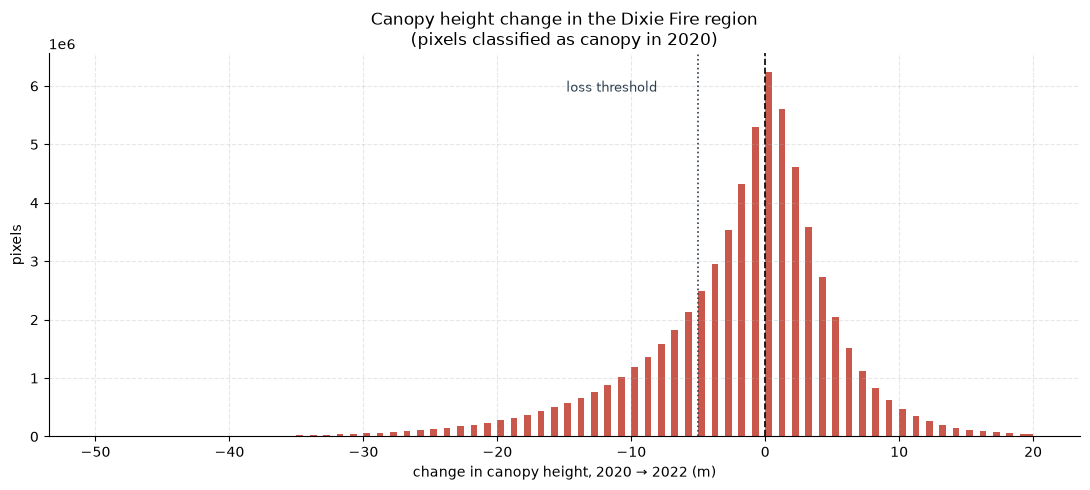

In [ ]:
# Counts came from the single pass above; NaNs fall outside `range` and are
# simply not counted.
counts = R["hist_counts"]
edges = np.linspace(-50, 20, 141)

fig, ax = plt.subplots(figsize=(11, 5))
ax.stairs(counts, edges, fill=True, color="#c0392b", alpha=0.85)
ax.axvline(0, color="black", linewidth=1.2, linestyle="--")
ax.axvline(LOSS_THRESHOLD_M, color="#2c3e50", linewidth=1.2, linestyle=":")
ax.annotate("loss threshold", (LOSS_THRESHOLD_M, ax.get_ylim()[1] * 0.9),
            xytext=(-95, 0), textcoords="offset points", fontsize=9, color="#2c3e50")
ax.set_xlabel("change in canopy height, 2020 → 2022 (m)")
ax.set_ylabel("pixels")
ax.set_title("Canopy height change in the caldor Fire region\n"
             "(pixels classified as canopy in 2020)")
ax.grid(True, alpha=0.3, linestyle="--")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

#### How to read this result

Three caveats matter for interpretation, and none of them is a defect in the data.

**These are optically-derived heights.** The underlying predictions come from NAIP
aerial imagery, so what the difference measures is the loss of *green canopy*, not
necessarily the loss of stems. A stand of fire-killed trees that is still standing has
lost its crown but retains its structure; this dataset records it as canopy loss. For
most carbon and habitat questions that is the right answer, but it is not the
measurement a lidar survey would give you.

**`tree_height` is a median.** Within each 5 m cell the value is robust to a few
surviving tall crowns rather than sensitive to them, so the signal here is
conservative: a cell has to lose most of its canopy before the median moves much.

**The detected scar is canopy loss, not fire.** Everything that changed between the two
flights lands in it — including salvage logging, which was extensive in this area after
2021, and any unrelated harvest. The detected area will not match the official fire
perimeter, and the difference between the two is itself informative. Overlaying the
MTBS or NIFC perimeter would separate them, which leads directly to the next question.

### Q: What is one unanswered question that could be answered using these data?

**Can canopy height change be used to map burn severity directly, and does it predict
post-fire recovery better than reflectance-based severity indices?**

Burn severity is conventionally mapped from spectral change — MTBS and similar products
derive it from Landsat dNBR, which measures how *surface reflectance* changed. That is
a proxy. What land managers and carbon accountants actually want to know is how much
canopy structure was lost, and this dataset measures that directly at 5 m, across all of
CONUS, with NAIP's repeat cycle bracketing most recent large fires.

Concretely, someone could:

1. **Separate fire from salvage.** Intersect the detected loss mask above with the
   official MTBS perimeter. Loss inside the perimeter is plausibly fire; a sizeable
   patch of loss outside it is probably harvest. How much of the total is which?
2. **Calibrate structural loss against established severity classes.** Join the height
   difference to MTBS severity polygons and ask how separable the classes are in terms
   of canopy height loss. Where do they disagree, and is the disagreement systematic —
   in stands that were already open, for instance?
3. **Test whether structure predicts recovery.** NAIP keeps flying, so states on a
   two-year cycle will have a third and fourth acquisition after these fires. Does
   pre-fire canopy height predict regrowth rate, independent of severity class?
4. **Scale it to every recent large fire in CONUS.** The per-state group layout makes
   this straightforwardly parallel: one worker per state, each opening its own group.

**Recommendations for someone tackling this:**

- **Keep reads lazy and let Dask do the work.** Open with `chunks={}`, crop *before* you
  compute, and never call `.values` on a window this size — use `dask.array.histogram`
  and lazy reductions, as above.
- **Check each state's time axis.** They differ, and four states have non-contiguous
  year sets. A fire needs a flight on each side of it to be usable, and not every fire
  has one.
- **Always mask the fill value, and always require validity in both years** before
  differencing.
- **Never count pixels for area.** Use the `cell_area_m2` helper above, or reproject to
  an equal-area CRS (EPSG:5070 for CONUS, EPSG:6933 globally) first.
- **Watch your denominator.** As shown above, the same fire looks mild or catastrophic
  depending on whether you average over the window or over the burned area.
- **Consider the sibling 30 m dataset** for regional work. Same area, same variables plus
  `tree_height_mean` and `tree_height_std`, at roughly 1/40th the pixels. The two grids
  are deliberately *not* pixel-nested, so comparing them requires an explicit resample.

We would be glad to see what you find.

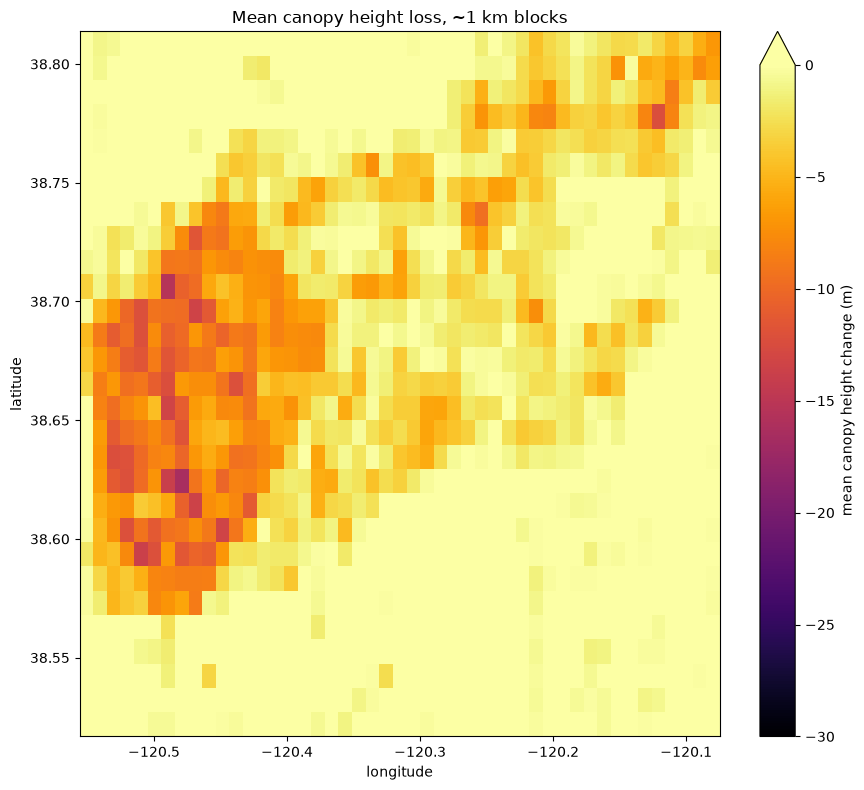

wrote caldor_canopy_loss_1km.tif

Next step: overlay the MTBS perimeter and severity classes for the Dixie Fire
to separate fire-driven loss from post-fire salvage, and test how well
structural loss reproduces the established severity classes.


In [ ]:
# Starter: where was canopy loss most severe? Aggregate onto ~1 km blocks to rank
# the worst-hit areas, then export for joining to a severity product.

BLOCK = 256   # ~1.13 km, and a divisor of the 512-px chunk -- see the note above

block_loss = delta_canopy.coarsen(y=BLOCK, x=BLOCK, boundary="trim").mean().compute()

fig, ax = plt.subplots(figsize=(9, 8))
block_loss.plot(ax=ax, vmin=-30, vmax=0, cmap="inferno",
                cbar_kwargs={"label": "mean canopy height change (m)"})
ax.set_title("Mean canopy height loss, ~1 km blocks")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
plt.tight_layout()
plt.show()

# Export for a GIS join against MTBS severity polygons.x
block_loss.rio.write_crs("EPSG:4326").rio.to_raster(
    "caldor_canopy_loss_1km.tif", compress="LZW"
)
print("wrote caldor_canopy_loss_1km.tif")
print()
print("Next step: overlay the MTBS perimeter and severity classes for the Caldor Fire")
print("to separate fire-driven loss from post-fire salvage, and test how well")
print("structural loss reproduces the established severity classes.")